In [2]:
import numpy as np
import pandas as pd

In [3]:
rd = pd.read_csv("R&D.csv", skiprows=4)

In [4]:
print(rd.head())
print(rd.columns)

                  Country Name Country Code  \
0                        Aruba          ABW   
1  Africa Eastern and Southern          AFE   
2                  Afghanistan          AFG   
3   Africa Western and Central          AFW   
4                       Angola          AGO   

                                    Indicator Name     Indicator Code  1960  \
0  Research and development expenditure (% of GDP)  GB.XPD.RSDV.GD.ZS   NaN   
1  Research and development expenditure (% of GDP)  GB.XPD.RSDV.GD.ZS   NaN   
2  Research and development expenditure (% of GDP)  GB.XPD.RSDV.GD.ZS   NaN   
3  Research and development expenditure (% of GDP)  GB.XPD.RSDV.GD.ZS   NaN   
4  Research and development expenditure (% of GDP)  GB.XPD.RSDV.GD.ZS   NaN   

   1961  1962  1963  1964  1965  ...  2017  2018      2019  2020  2021  2022  \
0   NaN   NaN   NaN   NaN   NaN  ...   NaN   NaN       NaN   NaN   NaN   NaN   
1   NaN   NaN   NaN   NaN   NaN  ...   NaN   NaN       NaN   NaN   NaN   NaN   
2 

In [5]:
rd_long = rd.melt(
    id_vars=["Country Name", "Country Code"],
    var_name="year",
    value_name="rd"
)

In [6]:
rd_long = rd_long.rename(columns={
    "Country Name": "country",
    "Country Code": "countrycode"
})

In [7]:
rd_long = rd_long[rd_long["year"].str.isnumeric()]
rd_long["year"] = rd_long["year"].astype(int)

In [8]:
rd_long = rd_long[(rd_long["year"] >= 1990) & (rd_long["year"] <= 2025)]

In [9]:
rd_long = rd_long.dropna(subset=["rd"])

In [10]:
rd_long = rd_long[rd_long["countrycode"].str.len() == 3]

In [11]:
rd_long.describe()

,year
count,3199.000000
mean,2010.235699
std,7.787963
min,1996.000000
25%,2004.000000
50%,2010.000000
75%,2017.000000
max,2024.000000


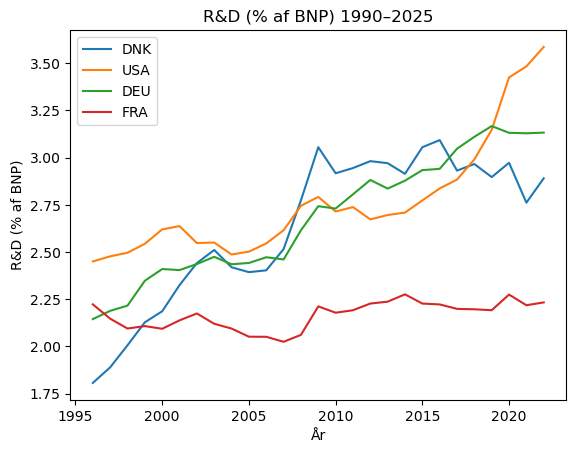

In [ ]:
import matplotlib.pyplot as plt

countries = ["DNK", "USA", "DEU", "FRA"]

for c in countries:
    temp = rd_long[rd_long["countrycode"] == c].sort_values("year")
    plt.plot(temp["year"], temp["rd"], label=c)

plt.legend()
plt.title("R&D (% af BNP) 1990–2025")
plt.xlabel("År")
plt.ylabel("R&D (% af BNP)")
plt.show()

In [12]:
rd_avg = (
    rd_long
    .groupby("countrycode")["rd"]
    .mean()
    .reset_index()
)